# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [1]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad
import zipfile
from pathlib import Path
import tempfile

# %matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import from the modules
from parsers.vneometh.vneo_method import VNeoMethod
from parsers.vneometh.lc_method_collection import VNeoMethodCollection
from parsers.timsmeth.ms_method import MicroTOFMethod
from parsers.timsmeth.ms_method_collection import MSMethodCollection
from parsers.diann.anndiannloader import DiannLoader
from parsers.diann.diann_collection import DiannCollection
from parsers.diann.diann_plotting import *

from parsers.bps.bps_loader import BPSLoader
from parsers.bps.bps_collection import BPSCollection
from parsers.bps.bps_plotting import *

# Integrator tools
from integrator.filters import filter_mask
from integrator.method_mapper import map_lcms_methods

# Import the NEW .NET Core pressure extraction functionality
from parsers.vneometh.extractor.raw_extractor_dotnet import extract_raw, extract_method

from plotting.dash import DashPlots

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [4]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

## Base

In [5]:
source = 'base'

In [6]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Load LC Methods

In [7]:
lccollection = VNeoMethodCollection()
lccollection.add_methods_from_folder(f'/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/methods/LC/VNTT_260428')

Index(['time [min]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]',
       'Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Curve',
       'Neo.PumpModule.Pump.StartColumnWash', 'length [min]'],
      dtype='object')


(<Axes: title={'center': 'Gradient Comparison'}, xlabel='time [min]', ylabel='Value'>,
 <Axes: ylabel='Neo.PumpModule.Pump.Flow.Nominal [µl/min]'>)

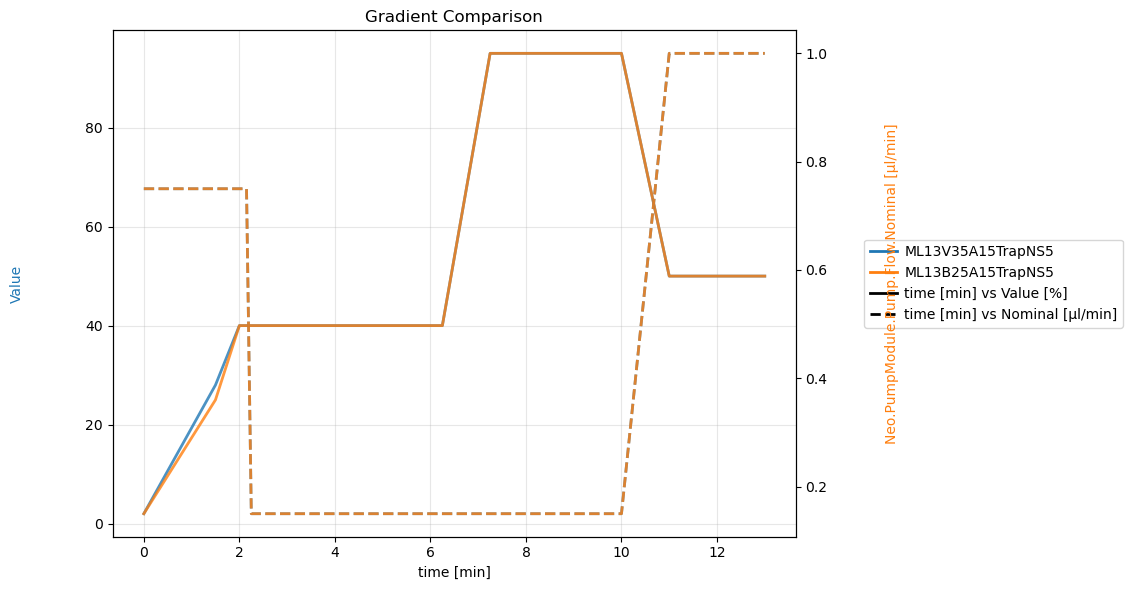

In [62]:
lccollection.plot_gradients(method_names = ['ML13V35A15TrapNS5', 'ML13B25A15TrapNS5'], x_cols='time [min]', y_cols = ['Neo.PumpModule.Pump.%B.Value [%]', 'Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], twin_axes=True)

## MS Methods

### Load MS Methods

In [10]:
# Intialize MS method collector object
mscollection = MSMethodCollection()

In [11]:
mscollection.add_methods_from_folder(f"/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/methods/MS/VNTT_260428.zip")
msmethod_names = '\n'.join(mscollection.methods.keys())

### BPS

In [105]:
dn_collection = BPSCollection(search_type='bps_diann')
dn_collection.add_searches('/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/BPS/VNTT/ML13comp (2).zip')

Found 6 tims-diann.result.zip files

📊 Summary: Found 6 total samples
   UUIDs/samples: ['fff3a33f-37bc-43e9-ab24-c8a31e392c46', '8fe5e8d6-8b18-4ddd-8d0a-7b3ed41e8dab', '54220d9f-402c-4826-adaf-c1921c50f83f', '675e14ba-095e-4557-9220-8bfe8584b5a8', 'a770027c-f94f-456c-8346-1cbdcb77d4f4', 'c73b797b-ffba-443f-91b6-2a8cfd02393e']
Found 6 result samples (bps_diann format)

Processing fff3a33f-37bc-43e9-ab24-c8a31e392c46
  Loading precursor level...
    ✓ precursor: (56660, 43)
  Loading protein level...
    ✓ protein: (8710, 23)
  Loading gene level...
⚠ Could not load gene level: 
cannot access free variable 'pr_obs' where it is not associated with a value in enclosing scope

Processing 8fe5e8d6-8b18-4ddd-8d0a-7b3ed41e8dab
  Loading precursor level...
    ✓ precursor: (53379, 43)
  Loading protein level...
    ✓ protein: (8228, 23)
  Loading gene level...
⚠ Could not load gene level: 
cannot access free variable 'pr_obs' where it is not associated with a value in enclosing scope

Processi

In [106]:
df = map_lcms_methods(dn_collection, ['/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT001_combined.csv',
                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT003_combined.csv',
                                  '/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/data/sequences/vntt/VNTT006_combined.csv'])

In [130]:
meth1 = lccollection.methods['ML13B25A15TrapNS5'].copy()
meth2 = lccollection.methods['ML13V35A15TrapNS5'].copy()

In [137]:
dn_collection['precursor'].var

,File.Name,Run,search_type,hystar_index,lc meth,ms meth,raw file,lcms method
File.Name,,,,,,,,
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012915_VNTT006_timsTOF_B-H2_1_15708,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,analysis,bps_diann,15708,ML13V35A15TrapNS5,DIA003,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,ML13V35A15TrapNS5_DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012911_VNTT006_timsTOF_B-H2_1_15704,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,analysis,bps_diann,15704,ML13B25A15TrapNS5,DIA003,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,ML13B25A15TrapNS5_DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012913_VNTT006_timsTOF_B-H2_1_15706,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,analysis,bps_diann,15706,ML13V35A15TrapNS5,DIA003,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,ML13V35A15TrapNS5_DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012908_VNTT006_timsTOF_B-H2_1_15702,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,analysis,bps_diann,15702,ML13B25A15TrapNS5,DIA003,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,ML13B25A15TrapNS5_DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012918_VNTT006_timsTOF_B-H2_1_15710,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,analysis,bps_diann,15710,ML13V35A15TrapNS5,DIA003,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS...,ML13V35A15TrapNS5_DIA003
HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012906_VNTT006_timsTOF_B-H2_1_15700,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,analysis,bps_diann,15700,ML13B25A15TrapNS5,DIA003,HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS...,ML13B25A15TrapNS5_DIA003


In [139]:
meth1_rep = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13V35A15TrapNS5_012915_VNTT006_timsTOF_B-H2_1_15708']
meth2_rep = dn_collection['precursor'][:, 'HeLaI5ng_Ddil_F1_R1_T1_DIA003-ML13B25A15TrapNS5_012908_VNTT006_timsTOF_B-H2_1_15702']

In [151]:
np.nanmin(meth2_rep.layers['RT'].flatten())

array(2.32069302)

In [155]:
meth1.gradient

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,Neo.PumpModule.Pump.StartColumnWash,length [min],volume (nL),total volume (nL),Dead Volume Used (nL),Total + Dead Volume (nL),Trapped %B Contribution,Actual Time to Elute Nominal %B (min),Base Actual %B,Actual %B
0,0.00,0.75,2.0,5,NaN,0.00,0.0,0.0,1638.0,1638.0,0.0,2.3200,2.000000,2.000000
1,1.50,0.75,25.0,5,NaN,1.50,1125.0,1125.0,1638.0,2763.0,0.0,9.8200,2.000000,2.000000
2,2.00,0.75,40.0,5,NaN,0.50,375.0,1500.0,1638.0,3138.0,0.0,10.3480,2.000000,2.000000
3,2.15,0.75,40.0,5,NaN,0.15,112.5,1612.5,1638.0,3250.5,0.0,10.4605,2.000000,2.000000
4,2.25,0.15,40.0,5,NaN,0.10,15.0,1627.5,1638.0,3265.5,0.0,10.4755,2.000000,2.000000
5,6.25,0.15,40.0,5,1.0,4.00,600.0,2227.5,1638.0,3865.5,0.0,11.0755,14.052000,14.052000
6,7.25,0.15,95.0,5,NaN,1.00,150.0,2377.5,1638.0,4015.5,0.0,11.2255,17.118667,17.118667
7,10.00,0.15,95.0,5,NaN,2.75,412.5,2790.0,1638.0,4428.0,0.0,11.6380,30.113636,30.113636
8,11.00,1.00,50.0,5,NaN,1.00,1000.0,3790.0,1638.0,5428.0,0.0,12.6380,40.000000,40.000000
9,13.00,1.00,50.0,5,NaN,2.00,2000.0,5790.0,1638.0,7428.0,0.0,13.0000,50.000000,50.000000


Text(0.5, 1.0, 'Precursor Distribution with Gradient Change')

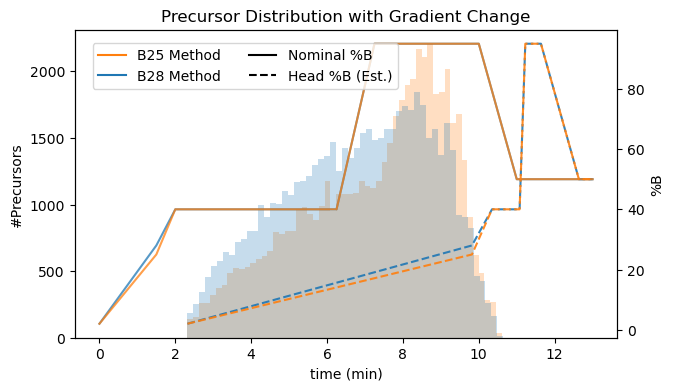

In [198]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(meth2_rep.layers['RT'].flatten(), label='B25', color='tab:orange', edgecolor=None, alpha=0.25, ax=ax)
sns.histplot(meth1_rep.layers['RT'].flatten(), label='B35', color='tab:blue', edgecolor=None, alpha=0.25, ax=ax)

ax2 = ax.twinx()

meth1.adjusted_elution(in_place = True, dead_time=2.32)
meth2.adjusted_elution(in_place = True, dead_time=2.32)

sns.lineplot(data=meth2.gradient, x= 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', color='tab:blue', ax=ax2, alpha=0.75, label='B35 Nominal %B')
sns.lineplot(data=meth2.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', color='tab:blue', ax=ax2, linestyle='--', alpha=0.9, label='B35 Head %B')

sns.lineplot(data=meth1.gradient, x= 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', color='tab:orange', ax=ax2, alpha=0.75, label='B25 Nominal %B')
sns.lineplot(data=meth1.gradient, x= 'Actual Time to Elute Nominal %B (min)', y='Neo.PumpModule.Pump.%B.Value [%]', color='tab:orange', ax=ax2, linestyle='--', alpha=0.9, label='B25 Head %B')


ax.set_ylabel('#Precursors')
ax2.set_ylabel('%B')
ax.set_xlabel('time (min)')

# Create custom legend entries
import matplotlib.lines as mlines
# Method colors
b25_line = mlines.Line2D([], [], color='tab:orange', label='B25 Method')
b35_line = mlines.Line2D([], [], color='tab:blue', label='B28 Method')
# Line styles
nominal_line = mlines.Line2D([], [], color='black', linestyle='-', label='Nominal %B')
head_line = mlines.Line2D([], [], color='black', linestyle='--', label='Head %B (Est.)')

# Create single legend with all elements
ax2.legend(handles=[b25_line, b35_line, nominal_line, head_line], 
          loc='upper left', bbox_to_anchor=(0.02, 0.98), ncol=2)

plt.title('Precursor Distribution with Gradient Change')

In [107]:
dn_collection['precursor'].var['lcms method'] = dn_collection['precursor'].var['lc meth'] + '_' + dn_collection['precursor'].var['ms meth']

In [108]:
dn_collection['protein'].var['lcms method'] = dn_collection['protein'].var['lc meth'] + '_' + dn_collection['precursor'].var['ms meth']

In [109]:
def get_group_values(collection, agg_cols, group_element_cols, level, layer):
    ad = collection[level]
    grouped = ad.var.groupby(agg_cols).agg(list)[group_element_cols]

    # Initialize result DataFrame with precursors as rows
    result_data = {}
    
    for agg_value, group_files in grouped.items():
        # Use the aggregation column value as the group key
        group_key = agg_value
        # Create a readable group name for column headers
        group_name = str(group_key)
        
        mask = ad.var[group_element_cols].isin(group_files)
        temp = ad[:, mask]
        
        extracted_layer = temp.layers[layer]
        # Convert to numpy array and ensure it's float type for calculations
        extracted_layer = np.array(extracted_layer, dtype=float)
        
        num_reps = np.sum(extracted_layer > 0, axis=1)
        
        # Handle division by zero and NaN values
        mean_vals = np.mean(extracted_layer, axis=1)
        std_vals = np.std(extracted_layer, axis=1)
        cv = np.where(mean_vals != 0, (std_vals / mean_vals) * 100, np.nan)
        
        avg = mean_vals
        log2_avg = np.log2(avg + 1)
        
        # Add columns for this group
        result_data[f'{group_name}_num_reps'] = num_reps
        result_data[f'{group_name}_cv'] = cv
        result_data[f'{group_name}_avg'] = avg
        result_data[f'{group_name}_log2_avg'] = log2_avg
    
    # Create DataFrame with precursors as rows and group-metric combinations as columns
    result_df = pd.DataFrame(result_data, index=ad.obs.index)
    
    return result_df

In [110]:
summary = get_group_values(dn_collection, ['lcms method'], 'File.Name', 'precursor', 'Precursor.Quantity')

In [111]:
prot_summary = get_group_values(dn_collection, ['lc meth'], 'File.Name', 'protein', 'PG.Quantity')

NameError: name 'trap_v_direct_prot_summary' is not defined

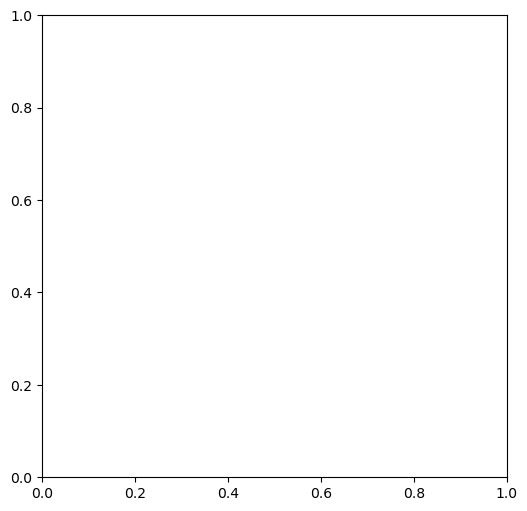

In [112]:
fig, ax = plt.subplots(figsize=(6, 6))

sns.scatterplot(data=trap_v_direct_prot_summary , x='20m150nlML30mA15phospho4_log2_avg', y='33ML6mlInlineA15TrapNS5_log2_avg', alpha=0.5, s=2, ax=ax)
sns.histplot(data=trap_v_direct_prot_summary , x='20m150nlML30mA15phospho4_log2_avg', y='33ML6mlInlineA15TrapNS5_log2_avg', alpha=0.25,  kde=True, ax=ax)

# Add x=y diagonal line
xlims = ax.get_xlim()
ylims = ax.get_ylim()

ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_ylabel('Trap Inject Log2 Avg. Intensity', fontsize=12)
ax.set_xlabel('Direct Inject Log2 Avg. Intensity', fontsize=12)

ML13B25A15TrapNS5_DIA003: 3 samples, counts: [np.int64(53379), np.int64(54833), np.int64(53278)]
ML13V35A15TrapNS5_DIA003: 3 samples, counts: [np.int64(56660), np.int64(55611), np.int64(54975)]


/hpc/mydata/eileen.wang/anaconda/25.3.1/x86_64/envs/methodanalysis/lib/python3.11/site-packages/anndata/_core/views.py:151: RuntimeWarning: invalid value encountered in greater
  results = super().__array_ufunc__(


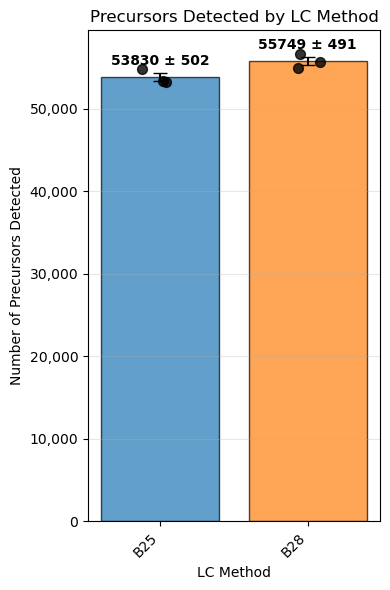


Detailed Statistics:
ML13B25A15TrapNS5_DIA003:
  Samples: 3
  Individual counts: [np.int64(53379), np.int64(54833), np.int64(53278)]
  Mean: 53830.0
  Std Dev: 870.1
  Std Error: 502.3
  Range: 53278 - 54833

ML13V35A15TrapNS5_DIA003:
  Samples: 3
  Individual counts: [np.int64(56660), np.int64(55611), np.int64(54975)]
  Mean: 55748.7
  Std Dev: 850.9
  Std Error: 491.3
  Range: 54975 - 56660



In [197]:
# Define the first 2 LC-MS methods
methods = ['ML13B25A15TrapNS5_DIA003', 'ML13V35A15TrapNS5_DIA003']
method_labels = ['B25', 'B28']

# Get tab10 colors
tab10_colors = plt.cm.tab10.colors

# Get individual sample data for each method
sample_data = {}
sample_counts_all = []

for method in methods:
    # Get the files for this method from the collection
    ad = dn_collection['precursor']
    method_mask = ad.var['lcms method'] == method
    method_files = ad.var[method_mask]['File.Name'].unique()
    
    # Count precursors detected in each individual sample
    sample_counts = []
    for file in method_files:
        file_mask = ad.var['File.Name'] == file
        file_data = ad[:, file_mask]
        
        # Count precursors with non-zero values in this file
        precursor_layer = file_data.layers['Precursor.Quantity']
        detected_count = np.sum(precursor_layer > 0, axis=0)[0]  # Sum across precursors for this file
        sample_counts.append(detected_count)
    
    sample_data[method] = sample_counts
    sample_counts_all.extend(sample_counts)
    print(f"{method}: {len(method_files)} samples, counts: {sample_counts}")

# Calculate means and standard errors
means = []
std_errors = []
all_individual_data = []

for method in methods:
    counts = sample_data[method]
    means.append(np.mean(counts))
    std_errors.append(np.std(counts, ddof=1) / np.sqrt(len(counts)))  # Standard error
    all_individual_data.append(counts)

# Create the plot
fig, ax = plt.subplots(figsize=(4, 6))

# Plot bars with error bars
x_positions = np.arange(len(methods))
bars = ax.bar(x_positions, means, yerr=std_errors, capsize=5, 
              color=[tab10_colors[i] for i in range(len(methods))], 
              alpha=0.7, edgecolor='black', linewidth=1)

# Plot individual sample points
for i, (method, counts) in enumerate(zip(methods, all_individual_data)):
    # Add some jitter to x-position for better visibility
    jitter = np.random.normal(0, 0.05, len(counts))
    x_points = np.full(len(counts), i) + jitter
    ax.scatter(x_points, counts, color='black', s=50, alpha=0.8, zorder=5)

# Add value labels on top of each bar (mean ± SE)
for i, (bar, mean, se) in enumerate(zip(bars, means, std_errors)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(means)*0.02,
            f'{mean:.0f} ± {se:.0f}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

# Customize plot
ax.set_xlabel('LC Method')
ax.set_ylabel('Number of Precursors Detected')
ax.set_title('Precursors Detected by LC Method')

# Set x-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels(method_labels, rotation=45, ha='right')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3)

# Format y-axis to show thousands separator
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nDetailed Statistics:")
for method, counts in sample_data.items():
    mean_val = np.mean(counts)
    std_val = np.std(counts, ddof=1)
    se_val = std_val / np.sqrt(len(counts))
    print(f"{method}:")
    print(f"  Samples: {len(counts)}")
    print(f"  Individual counts: {counts}")
    print(f"  Mean: {mean_val:.1f}")
    print(f"  Std Dev: {std_val:.1f}")
    print(f"  Std Error: {se_val:.1f}")
    print(f"  Range: {min(counts)} - {max(counts)}")
    print()

In [81]:
test = dn_collection['protein'].to_df('PG.Quantity')
test[dn_collection['protein'].to_df('PG.Q.Value') > 0.01] = np.nan

In [98]:
# Check protein data layers to understand the quantification structure
ad = dn_collection['protein']
method_mask = ad.var['lcms method'] == 'ML13B25A15TrapNS5_DIA003'
method_files = ad.var[method_mask]['File.Name'].unique()

if len(method_files) > 0:
    file_mask = ad.var['File.Name'] == method_files[0]
    file_data = ad[:, file_mask]
    
    print(f"Available layers: {list(file_data.layers.keys())}")
    
    for layer in ['PG.Quantity', 'PG.MaxLFQ', 'PG.Normalised']:
        layer_data = file_data.layers[layer]
        print(f"\n{layer}:")
        print(f"  Shape: {layer_data.shape}")
        print(f"  Non-zero count: {np.sum(layer_data > 0)}")
        print(f"  Non-NaN count: {np.sum(~np.isnan(layer_data))}")
        print(f"  Min: {np.nanmin(layer_data)}")
        print(f"  Max: {np.nanmax(layer_data)}")
        
    # Check if there's a way to identify detected proteins
    # Let's see what the original working version used
    print(f"\nQ-values:")
    q_values = file_data.layers['PG.Q.Value']
    print(f"  Non-NaN Q-values: {np.sum(~np.isnan(q_values))}")
    print(f"  Q-values <= 0.01 (and non-NaN): {np.sum((q_values <= 0.01) & (~np.isnan(q_values)))}")
    
    # Check what happens when we look at non-NaN q-values
    valid_detections = ~np.isnan(q_values)
    print(f"  Valid detections (non-NaN Q-values): {np.sum(valid_detections)}")

Available layers: ['PG.MaxLFQ', 'PG.Quantity', 'PG.Normalised', 'Protein.Q.Value', 'PG.Q.Value']

PG.Quantity:
  Shape: (12779, 1)
  Non-zero count: 0
  Non-NaN count: 0
  Min: nan
  Max: nan

PG.MaxLFQ:
  Shape: (12779, 1)
  Non-zero count: 8228
  Non-NaN count: 8228
  Min: 695.000061
  Max: 7814208.5

PG.Normalised:
  Shape: (12779, 1)
  Non-zero count: 8228
  Non-NaN count: 8228
  Min: 695.0
  Max: 26566736.0

Q-values:
  Non-NaN Q-values: 8228
  Q-values <= 0.01 (and non-NaN): 8228
  Valid detections (non-NaN Q-values): 8228


/tmp/ipykernel_3525327/2152441971.py:18: RuntimeWarning: All-NaN axis encountered
  print(f"  Min: {np.nanmin(layer_data)}")
/tmp/ipykernel_3525327/2152441971.py:19: RuntimeWarning: All-NaN axis encountered
  print(f"  Max: {np.nanmax(layer_data)}")


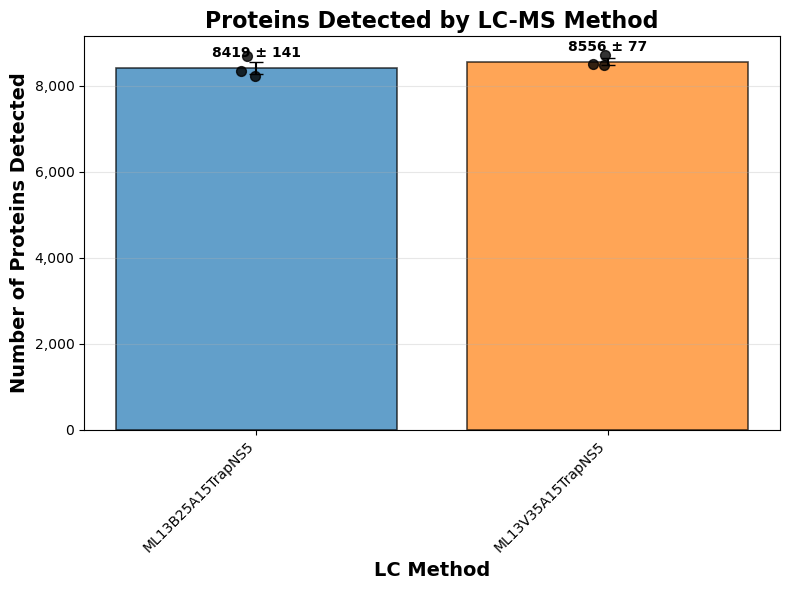


Detailed Statistics:
ML13B25A15TrapNS5_DIA003:
  Mean: 8419.3
  Std Dev: 243.9
  Std Error: 140.8
  Individual samples: [np.int64(8228), np.int64(8694), np.int64(8336)]

ML13V35A15TrapNS5_DIA003:
  Mean: 8556.3
  Std Dev: 133.6
  Std Error: 77.1
  Individual samples: [np.int64(8710), np.int64(8491), np.int64(8468)]



In [114]:
# Create bar plot for protein detection across two LC-MS methods
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# Only use first 2 methods
methods = methods[:2]

# Storage for individual sample data
sample_data = {}

for method in methods:
    # Get the files for this method from the collection
    ad = dn_collection['protein']
    method_mask = ad.var['lcms method'] == method
    method_files = ad.var[method_mask]['File.Name'].unique()
    
    # Count proteins detected in each individual sample
    sample_counts = []
    for file in method_files:
        file_mask = ad.var['File.Name'] == file
        file_data = ad[:, file_mask]
        
        # Count proteins with quantified values in this file
        protein_layer = file_data.layers['PG.MaxLFQ']
        detected_count = np.sum(~np.isnan(protein_layer), axis=0)[0]  # Sum across proteins for this file
        sample_counts.append(detected_count)
    
    sample_data[method] = sample_counts

# Calculate means and standard errors
means = [np.mean(sample_data[method]) for method in methods]
std_errors = [sem(sample_data[method]) for method in methods]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Set positions for bars
x_positions = np.arange(len(methods))

# Use tab10 colors
tab10_colors = plt.cm.tab10.colors
colors = [tab10_colors[i] for i in range(len(methods))]

# Create bars with error bars
bars = ax.bar(x_positions, means, yerr=std_errors, capsize=5, 
              color=colors, alpha=0.7, edgecolor='black', linewidth=1.2)

# Collect all individual data for plotting
all_individual_data = [sample_data[method] for method in methods]

# Plot individual sample points
for i, (method, counts) in enumerate(zip(methods, all_individual_data)):
    # Add some jitter to x-position for better visibility
    jitter = np.random.normal(0, 0.05, len(counts))
    x_points = np.full(len(counts), i) + jitter
    ax.scatter(x_points, counts, color='black', s=50, alpha=0.8, zorder=5)

# Add value labels on top of each bar (mean ± SE)
for i, (bar, mean, se) in enumerate(zip(bars, means, std_errors)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(means)*0.02,
            f'{mean:.0f} ± {se:.0f}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

# Customize plot
ax.set_xlabel('LC Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Proteins Detected', fontsize=14, fontweight='bold')
ax.set_title('Proteins Detected by LC-MS Method', 
             fontsize=16, fontweight='bold')

# Set x-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels(method_labels, rotation=45, ha='right')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3)

# Format y-axis to show thousands separator
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nDetailed Statistics:")
for method, counts in sample_data.items():
    mean_val = np.mean(counts)
    std_val = np.std(counts, ddof=1)  # Sample standard deviation
    se_val = sem(counts)  # Standard error
    print(f"{method}:")
    print(f"  Mean: {mean_val:.1f}")
    print(f"  Std Dev: {std_val:.1f}")
    print(f"  Std Error: {se_val:.1f}")
    print(f"  Individual samples: {counts}")
    print()

Method 1 (ML13B25A15TrapNS5_DIA003): 46540 proteins detected in ≥2 replicates
Method 2 (ML13V35A15TrapNS5_DIA003): 54571 proteins detected in ≥2 replicates
Method 3 (ML13V35A15TrapNS5_DIA003V1300): 54121 proteins detected in ≥2 replicates

Overlap Analysis:
Only Method 1: 2073 proteins
Only Method 2: 3870 proteins
Only Method 3: 3601 proteins
Method 1 & 2 only: 1422 proteins
Method 1 & 3 only: 1241 proteins
Method 2 & 3 only: 7475 proteins
All three methods: 41804 proteins


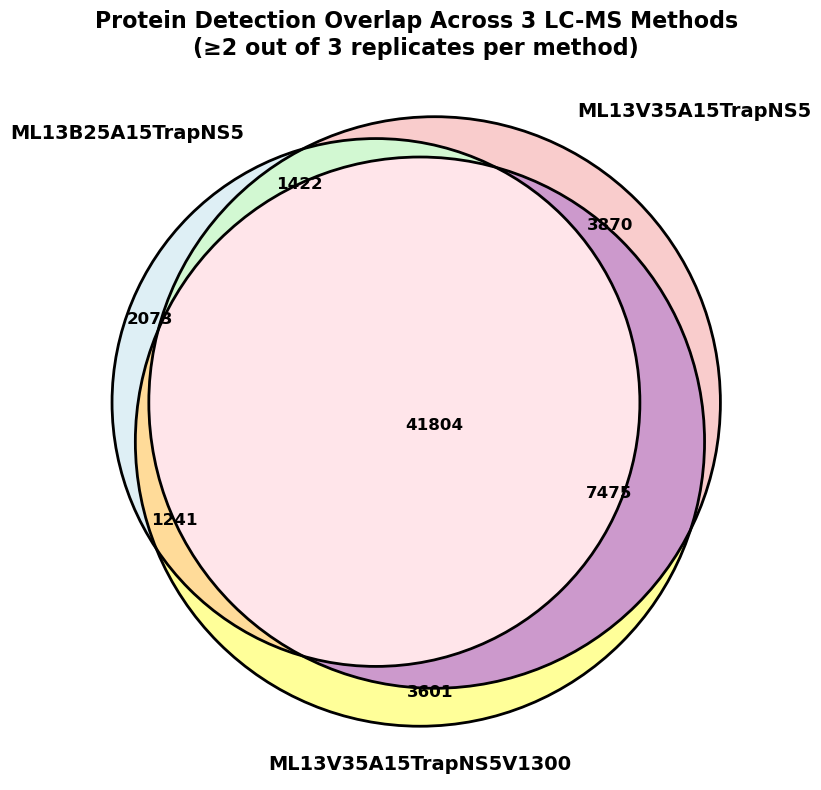


Overlap Statistics:
Core overlap represents 89.8% of ML13B25A15TrapNS5_DIA003 proteins
Core overlap represents 76.6% of ML13V35A15TrapNS5_DIA003 proteins
Core overlap represents 77.2% of ML13V35A15TrapNS5_DIA003V1300 proteins

Total unique proteins detected across all methods: 61486
Core overlap across all 3 methods: 41804 proteins (68.0% of total)


In [26]:
# Create 3-way Venn diagram for proteins identified in at least 2/3 replicates per group
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles

# Define the 3 LC-MS methods
method1 = 'ML13B25A15TrapNS5_DIA003'
method2 = 'ML13V35A15TrapNS5_DIA003'
method3 = 'ML13V35A15TrapNS5_DIA003V1300'

# Extract protein identifiers for proteins detected in ≥2 replicates
method1_col = f'{method1}_num_reps'
method2_col = f'{method2}_num_reps'
method3_col = f'{method3}_num_reps'

# Get proteins detected in ≥2 replicates for each method
method1_proteins = set(summary[summary[method1_col] >= 2].index)
method2_proteins = set(summary[summary[method2_col] >= 2].index)
method3_proteins = set(summary[summary[method3_col] >= 2].index)

print(f"Method 1 ({method1}): {len(method1_proteins)} proteins detected in ≥2 replicates")
print(f"Method 2 ({method2}): {len(method2_proteins)} proteins detected in ≥2 replicates")
print(f"Method 3 ({method3}): {len(method3_proteins)} proteins detected in ≥2 replicates")

# Calculate all possible intersections for the 3-way Venn diagram
# Venn3 requires: (Abc, aBc, ABc, abC, AbC, aBC, ABC)
# Where A=method1, B=method2, C=method3
# lowercase = not in set, uppercase = in set

only_1 = method1_proteins - method2_proteins - method3_proteins  # Abc
only_2 = method2_proteins - method1_proteins - method3_proteins  # aBc  
only_1_and_2 = (method1_proteins & method2_proteins) - method3_proteins  # ABc
only_3 = method3_proteins - method1_proteins - method2_proteins  # abC
only_1_and_3 = (method1_proteins & method3_proteins) - method2_proteins  # AbC
only_2_and_3 = (method2_proteins & method3_proteins) - method1_proteins  # aBC
all_three = method1_proteins & method2_proteins & method3_proteins  # ABC

print(f"\nOverlap Analysis:")
print(f"Only Method 1: {len(only_1)} proteins")
print(f"Only Method 2: {len(only_2)} proteins")
print(f"Only Method 3: {len(only_3)} proteins")
print(f"Method 1 & 2 only: {len(only_1_and_2)} proteins")
print(f"Method 1 & 3 only: {len(only_1_and_3)} proteins")
print(f"Method 2 & 3 only: {len(only_2_and_3)} proteins")
print(f"All three methods: {len(all_three)} proteins")

# Create 3-way Venn diagram
fig, ax = plt.subplots(figsize=(10, 8))
venn = venn3(subsets=(len(only_1), len(only_2), len(only_1_and_2), 
                      len(only_3), len(only_1_and_3), len(only_2_and_3), 
                      len(all_three)), 
             set_labels=('ML13B25A15TrapNS5', 'ML13V35A15TrapNS5', 'ML13V35A15TrapNS5V1300'),
             ax=ax)

# Customize colors
colors = ['lightblue', 'lightcoral', 'lightgreen', 'yellow', 'orange', 'purple', 'pink']
patch_ids = ['100', '010', '110', '001', '101', '011', '111']

for i, patch_id in enumerate(patch_ids):
    if venn.get_patch_by_id(patch_id):
        venn.get_patch_by_id(patch_id).set_color(colors[i])

# Customize text
for text in venn.set_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')

for text in venn.subset_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

# Add circles for better visibility
venn3_circles(subsets=(len(only_1), len(only_2), len(only_1_and_2), 
                       len(only_3), len(only_1_and_3), len(only_2_and_3), 
                       len(all_three)), ax=ax)

plt.title('Protein Detection Overlap Across 3 LC-MS Methods\n(≥2 out of 3 replicates per method)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate percentages
total_method1 = len(method1_proteins)
total_method2 = len(method2_proteins)
total_method3 = len(method3_proteins)

if total_method1 > 0:
    overlap_pct_1 = (len(all_three) / total_method1) * 100
    print(f"\nOverlap Statistics:")
    print(f"Core overlap represents {overlap_pct_1:.1f}% of {method1} proteins")
    
if total_method2 > 0:
    overlap_pct_2 = (len(all_three) / total_method2) * 100
    print(f"Core overlap represents {overlap_pct_2:.1f}% of {method2} proteins")
    
if total_method3 > 0:
    overlap_pct_3 = (len(all_three) / total_method3) * 100
    print(f"Core overlap represents {overlap_pct_3:.1f}% of {method3} proteins")

# Calculate total unique proteins across all methods
total_unique = len(method1_proteins | method2_proteins | method3_proteins)
print(f"\nTotal unique proteins detected across all methods: {total_unique}")
print(f"Core overlap across all 3 methods: {len(all_three)} proteins ({(len(all_three)/total_unique)*100:.1f}% of total)")

Text(0.5, 0, 'Direct Inject Log2 Avg. Intensity')

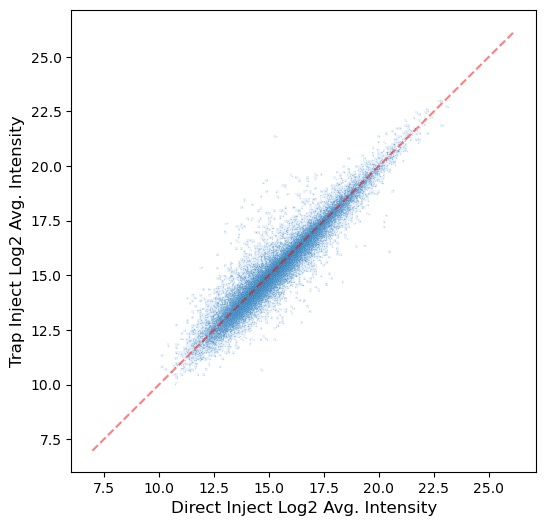

In [282]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, zorder=3)

sns.scatterplot(data=trap_v_direct_summary, x='20m150nlML30mA15phospho4_log2_avg', y='33ML6mlInlineA15TrapNS5_log2_avg', alpha=0.25, s=1, ax=ax)
sns.histplot(data=trap_v_direct_summary, x='20m150nlML30mA15phospho4_log2_avg', y='33ML6mlInlineA15TrapNS5_log2_avg', alpha=0.25,  kde=True, ax=ax)

# Add x=y diagonal line
xlims = ax.get_xlim()
ylims = ax.get_ylim()
min_val = min(xlims[0], ylims[0])
max_val = max(xlims[1], ylims[1])
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_ylabel('Trap Inject Log2 Avg. Intensity', fontsize=12)
ax.set_xlabel('Direct Inject Log2 Avg. Intensity', fontsize=12)

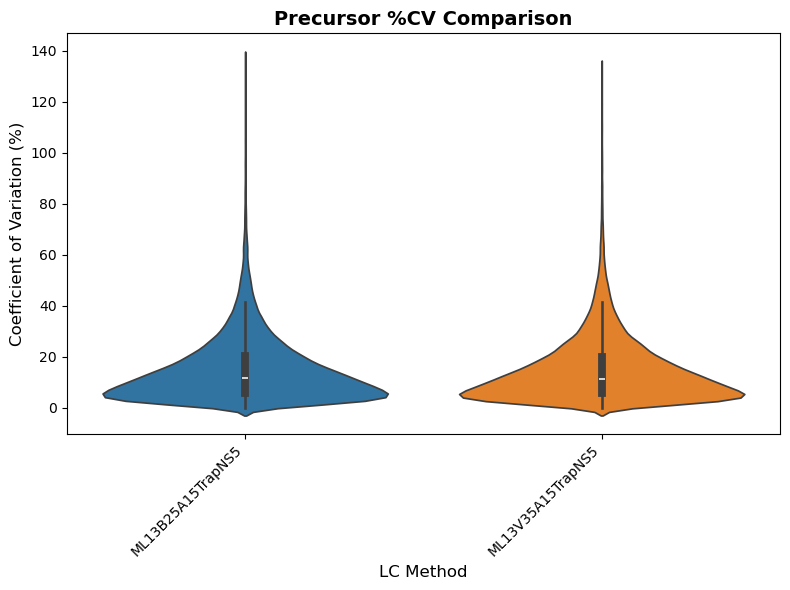


CV Summary Statistics:
ML13B25A15TrapNS5:
  Count: 43147
  Mean CV: 15.1%
  Median CV: 11.5%
  Std Dev: 13.1%

ML13V35A15TrapNS5:
  Count: 44905
  Mean CV: 15.0%
  Median CV: 11.5%
  Std Dev: 13.0%



In [117]:
# Filter out precursors identified in only 1 replicate and create CV violin plots
fig, ax = plt.subplots(figsize=(8, 6))

# Define our current method groups and their labels
methods = ['ML13B25A15TrapNS5_DIA003', 'ML13V35A15TrapNS5_DIA003']
method_labels = ['ML13B25A15TrapNS5', 'ML13V35A15TrapNS5']

# Filter data for precursors detected in ≥2 replicates in either method
filtered_data = summary[
    (summary[f'{methods[0]}_num_reps'] >= 2) |
    (summary[f'{methods[1]}_num_reps'] >= 2)
]

# Melt the data to create long format for grouped violin plots
cv_data = pd.melt(filtered_data, 
                  value_vars=[f'{methods[0]}_cv', f'{methods[1]}_cv'],
                  var_name='Method', value_name='CV')

# Map method names to cleaner labels
cv_data['Method'] = cv_data['Method'].map({
    f'{methods[0]}_cv': method_labels[0],
    f'{methods[1]}_cv': method_labels[1]
})

# Remove NaN values
cv_data = cv_data.dropna()

# Create violin plots
sns.violinplot(data=cv_data, x='Method', y='CV', hue='Method', ax=ax)
ax.set_title('Precursor %CV Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Coefficient of Variation (%)', fontsize=12)
ax.set_xlabel('LC Method', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nCV Summary Statistics:")
for method, label in zip(methods, method_labels):
    method_cv_data = filtered_data[f'{method}_cv'].dropna()
    if len(method_cv_data) > 0:
        print(f"{label}:")
        print(f"  Count: {len(method_cv_data)}")
        print(f"  Mean CV: {method_cv_data.mean():.1f}%")
        print(f"  Median CV: {method_cv_data.median():.1f}%")
        print(f"  Std Dev: {method_cv_data.std():.1f}%")
        print()
plt.show()


In [118]:
cv_data = pd.melt(trap_v_direct_prot_summary, 
                  value_vars=['20m150nlML30mA15phospho4_cv', '33ML6mlInlineA15TrapNS5_cv'],
                  var_name='Method', value_name='CV')

# Create violin plots on the same axis
plt.figure(figsize=(8, 6))
sns.violinplot(data=cv_data, x='Method', y='CV')
plt.xticks(rotation=45)
plt.title('CV Comparison Between Methods')
plt.tight_layout()
plt.show()

NameError: name 'trap_v_direct_prot_summary' is not defined

Replicate detection counts:
                   1 replicate  2 replicates  3 replicates
ML13B25A15TrapNS5        13121          9464         43147
ML13V35A15TrapNS5        13199          9666         44905


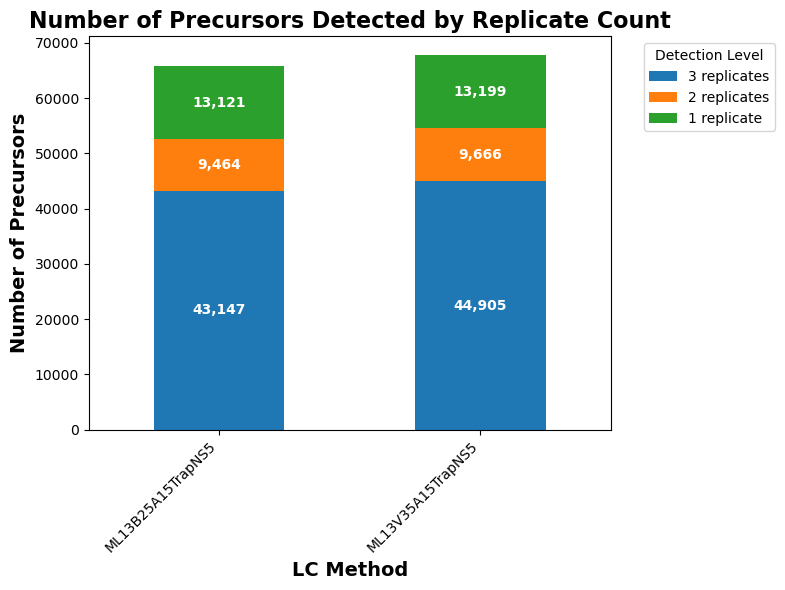


Detailed Replicate Statistics:

ML13B25A15TrapNS5:
  Total precursors: 65732
  1 replicate: 13121 (20.0%)
  2 replicates: 9464 (14.4%)
  3 replicates: 43147 (65.6%)
  ≥2 replicates: 52611 (80.0%)

ML13V35A15TrapNS5:
  Total precursors: 67770
  1 replicate: 13199 (19.5%)
  2 replicates: 9666 (14.3%)
  3 replicates: 44905 (66.3%)
  ≥2 replicates: 54571 (80.5%)


In [127]:
# Create stacked bar plot for replicate detection comparison
# First, prepare the data for stacked bar plot
rep_counts = {}

# Define our current method groups and their labels
methods = ['ML13B25A15TrapNS5_DIA003', 'ML13V35A15TrapNS5_DIA003']
method_labels = ['ML13B25A15TrapNS5', 'ML13V35A15TrapNS5']
rep_categories = ['1 replicate', '2 replicates', '3 replicates']

for i, method in enumerate(methods):
    rep_col = f'{method}_num_reps'
    if rep_col in summary.columns:
        # Use the values directly (they are already integers, not arrays)
        rep_values = summary[rep_col]
        
        # Count precursors by number of replicates
        rep_counts[method_labels[i]] = {
            '1 replicate': (rep_values == 1).sum(),
            '2 replicates': (rep_values == 2).sum(), 
            '3 replicates': (rep_values == 3).sum()
        }

# Convert to DataFrame for plotting
rep_df = pd.DataFrame(rep_counts).T
print("Replicate detection counts:")
print(rep_df)

# Reorder columns so 3 replicates is on bottom (first in stack)
column_order = ['3 replicates', '2 replicates', '1 replicate']
rep_df = rep_df[column_order]

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(8, 6))

# Use tab10 colors
tab10_colors = plt.cm.tab10.colors
plot_colors = [tab10_colors[i] for i in range(len(column_order))]

rep_df.plot(kind='bar', stacked=True, ax=ax, 
            color=plot_colors)

# Add text labels showing counts for each segment
for i, method_label in enumerate(method_labels):
    if method_label in rep_df.index:
        # Calculate positions for text labels in each segment
        bottom = 0
        for j, col in enumerate(column_order):
            value = rep_df.loc[method_label, col]
            if value > 0:  # Only add text if there's a value
                # Position text in the middle of each segment
                text_y = bottom + value / 2
                # Format numbers with thousands separator for readability
                label_text = f'{value:,}' if value >= 1000 else f'{value}'
                ax.text(i, text_y, label_text, ha='center', va='center', 
                       fontweight='bold', fontsize=10, color='white' if value > 5000 else 'black')
            bottom += value

# Add stripplot overlay showing individual sample replicate detection counts
import seaborn as sns
for i, method_label in enumerate(method_labels):
    # Get method-specific data
    method_mask = dn_collection['precursor'].obs[dn_collection['precursor'].obs.columns[0]] == method_label
    method_files = dn_collection['precursor'].obs[method_mask][dn_collection['precursor'].obs.columns[0]].unique()
    
    if len(method_files) > 0:
        # Count detections per precursor across replicates
        method_data = dn_collection['precursor'][method_mask]
        precursor_layer = method_data.layers['Precursor.Quantity']
        
        # Count how many replicates each precursor was detected in (non-zero values)
        replicate_counts = np.sum(~np.isnan(precursor_layer) & (precursor_layer > 0), axis=0)
        
        # Filter out precursors not detected in any replicate
        valid_counts = replicate_counts[replicate_counts > 0]
        
        if len(valid_counts) > 0:
            # Create jittered x-positions around the bar center
            x_base = i
            x_jitter = np.random.normal(0, 0.15, len(valid_counts))
            x_positions = x_base + x_jitter
            
            # Create stripplot with semi-transparent points
            ax.scatter(x_positions, valid_counts, alpha=0.3, s=1, color='red', edgecolors='darkred', linewidth=0.1)

plt.title('Number of Precursors Detected by Replicate Count', fontsize=16, fontweight='bold')
plt.xlabel('LC Method', fontsize=14, fontweight='bold')
plt.ylabel('Number of Precursors', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Detection Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nDetailed Replicate Statistics:")
for method_label in method_labels:
    if method_label in rep_df.index:
        total = rep_df.loc[method_label].sum()
        rep_1 = rep_df.loc[method_label, '1 replicate']
        rep_2 = rep_df.loc[method_label, '2 replicates'] 
        rep_3 = rep_df.loc[method_label, '3 replicates']
        
        print(f"\n{method_label}:")
        print(f"  Total precursors: {total}")
        print(f"  1 replicate: {rep_1} ({rep_1/total*100:.1f}%)")
        print(f"  2 replicates: {rep_2} ({rep_2/total*100:.1f}%)")
        print(f"  3 replicates: {rep_3} ({rep_3/total*100:.1f}%)")
        print(f"  ≥2 replicates: {rep_2+rep_3} ({(rep_2+rep_3)/total*100:.1f}%)")

In [25]:
# Create Venn diagram for proteins identified in at least 2/3 replicates per group
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

# Get proteins detected in ≥2 replicates for each method
method1 = '20m150nlML30mA15phospho4'
method2 = '33ML6mlInlineA15TrapNS5'

# Extract protein identifiers for proteins detected in ≥2 replicates
method1_col = f'{method1}_num_reps'
method2_col = f'{method2}_num_reps'

# Get proteins detected in ≥2 replicates for method 1
method1_proteins = set(summary[summary[method1_col] >= 2].index)
print(f"Method 1 ({method1}): {len(method1_proteins)} proteins detected in ≥2 replicates")

# Get proteins detected in ≥2 replicates for method 2  
method2_proteins = set(summary[trap_v_direct_summary[method2_col] >= 2].index)
print(f"Method 2 ({method2}): {len(method2_proteins)} proteins detected in ≥2 replicates")

# Calculate overlap
overlap = method1_proteins.intersection(method2_proteins)
print(f"Overlap: {len(overlap)} proteins detected in ≥2 replicates in both methods")
print(f"Method 1 only: {len(method1_proteins - method2_proteins)} proteins")
print(f"Method 2 only: {len(method2_proteins - method1_proteins)} proteins")

# Create Venn diagram
fig, ax = plt.subplots(figsize=(8, 6))
venn = venn2(subsets=(len(method1_proteins - method2_proteins), 
                      len(method2_proteins - method1_proteins), 
                      len(overlap)), 
             set_labels=('Direct Inject', 'Trap-and-Elute'),
             ax=ax)

# Customize colors
if venn.get_patch_by_id('10'):
    venn.get_patch_by_id('10').set_color('lightblue')
if venn.get_patch_by_id('01'):
    venn.get_patch_by_id('01').set_color('lightcoral')
if venn.get_patch_by_id('11'):
    venn.get_patch_by_id('11').set_color('lightgreen')

for text in venn.set_labels:
    if text:
        text.set_fontsize(18)
        text.set_fontweight('bold')

# Set subset number font sizes  
for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        text.set_fontweight('bold')

# Add circles for better visibility
venn2_circles(subsets=(len(method1_proteins - method2_proteins), 
                       len(method2_proteins - method1_proteins), 
                       len(overlap)), ax=ax)

plt.title('Protein Detection Overlap\n(≥2 out of 3 replicates per method)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate percentages
total_method1 = len(method1_proteins)
total_method2 = len(method2_proteins) 
overlap_pct_method1 = (len(overlap) / total_method1) * 100 if total_method1 > 0 else 0
overlap_pct_method2 = (len(overlap) / total_method2) * 100 if total_method2 > 0 else 0

print(f"\nOverlap Statistics:")
print(f"Overlap represents {overlap_pct_method1:.1f}% of {method1} proteins")
print(f"Overlap represents {overlap_pct_method2:.1f}% of {method2} proteins")

KeyError: '20m150nlML30mA15phospho4_num_reps'

Method 1 (20m150nlML30mA15phospho4): 9128 proteins detected in ≥2 replicates
Method 2 (33ML6mlInlineA15TrapNS5): 8953 proteins detected in ≥2 replicates
Overlap: 7881 proteins detected in ≥2 replicates in both methods
Method 1 only: 1247 proteins
Method 2 only: 1072 proteins


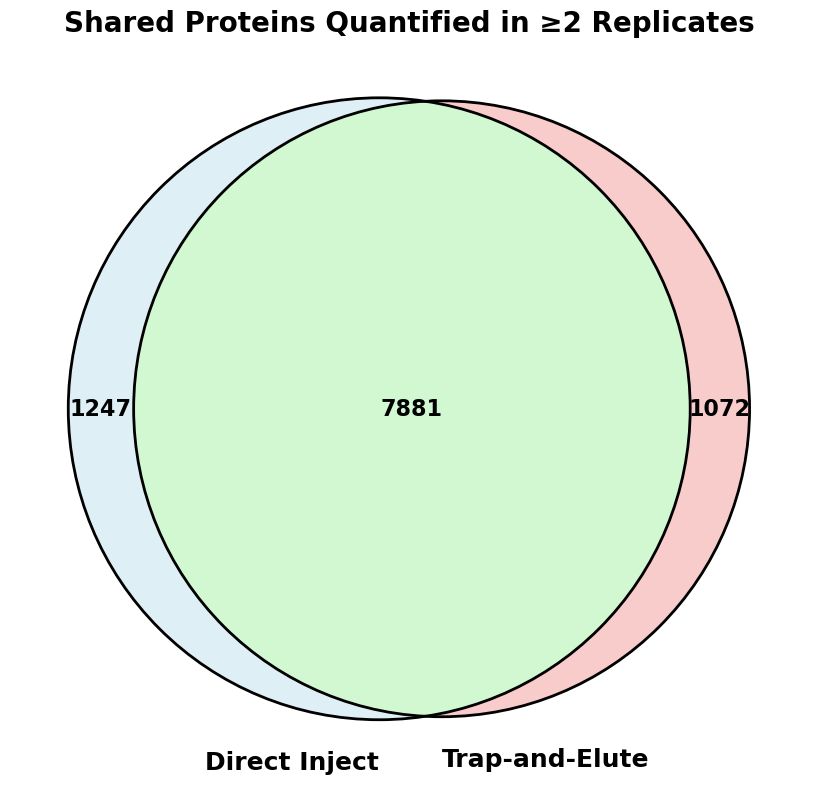


Overlap Statistics:
Overlap represents 86.3% of Direct Inject proteins
Overlap represents 88.0% of Trap-and-Elute proteins


In [307]:
# Create Venn diagram for proteins identified in at least 2/3 replicates per group
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

# Get proteins detected in ≥2 replicates for each method
method1 = '20m150nlML30mA15phospho4'
method2 = '33ML6mlInlineA15TrapNS5'

# Extract protein identifiers for proteins detected in ≥2 replicates
method1_col = f'{method1}_num_reps'
method2_col = f'{method2}_num_reps'

# Get proteins detected in ≥2 replicates for method 1
method1_proteins = set(trap_v_direct_prot_summary[trap_v_direct_prot_summary[method1_col] >= 2].index)
print(f"Method 1 ({method1}): {len(method1_proteins)} proteins detected in ≥2 replicates")

# Get proteins detected in ≥2 replicates for method 2  
method2_proteins = set(trap_v_direct_prot_summary[trap_v_direct_prot_summary[method2_col] >= 2].index)
print(f"Method 2 ({method2}): {len(method2_proteins)} proteins detected in ≥2 replicates")

# Calculate overlap
overlap = method1_proteins.intersection(method2_proteins)
print(f"Overlap: {len(overlap)} proteins detected in ≥2 replicates in both methods")
print(f"Method 1 only: {len(method1_proteins - method2_proteins)} proteins")
print(f"Method 2 only: {len(method2_proteins - method1_proteins)} proteins")

# Create Venn diagram
fig, ax = plt.subplots(figsize=(10, 8))
venn = venn2(subsets=(len(method1_proteins - method2_proteins), 
                      len(method2_proteins - method1_proteins), 
                      len(overlap)), 
             set_labels=('Direct Inject', 'Trap-and-Elute'),
             ax=ax)

# Customize colors
if venn.get_patch_by_id('10'):
    venn.get_patch_by_id('10').set_color('lightblue')
if venn.get_patch_by_id('01'):
    venn.get_patch_by_id('01').set_color('lightcoral')
if venn.get_patch_by_id('11'):
    venn.get_patch_by_id('11').set_color('lightgreen')

# Increase font sizes
# Set label font sizes
for text in venn.set_labels:
    if text:
        text.set_fontsize(18)
        text.set_fontweight('bold')

# Set subset number font sizes  
for text in venn.subset_labels:
    if text:
        text.set_fontsize(16)
        text.set_fontweight('bold')

# Add circles for better visibility
venn2_circles(subsets=(len(method1_proteins - method2_proteins), 
                       len(method2_proteins - method1_proteins), 
                       len(overlap)), ax=ax)

plt.title('Shared Proteins Quantified in ≥2 Replicates', 
          fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate percentages
total_method1 = len(method1_proteins)
total_method2 = len(method2_proteins) 
overlap_pct_method1 = (len(overlap) / total_method1) * 100 if total_method1 > 0 else 0
overlap_pct_method2 = (len(overlap) / total_method2) * 100 if total_method2 > 0 else 0

print(f"\nOverlap Statistics:")
print(f"Overlap represents {overlap_pct_method1:.1f}% of Direct Inject proteins")
print(f"Overlap represents {overlap_pct_method2:.1f}% of Trap-and-Elute proteins")

CV and Replicate Distribution (proteins detected in ≥2 replicates):
                CV<10%, 3 reps  CV 10-20%, 3 reps  CV≥20%, 3 reps
Direct Inject            23928              15091           11467
Trap-and-Elute           23668              14859           10098


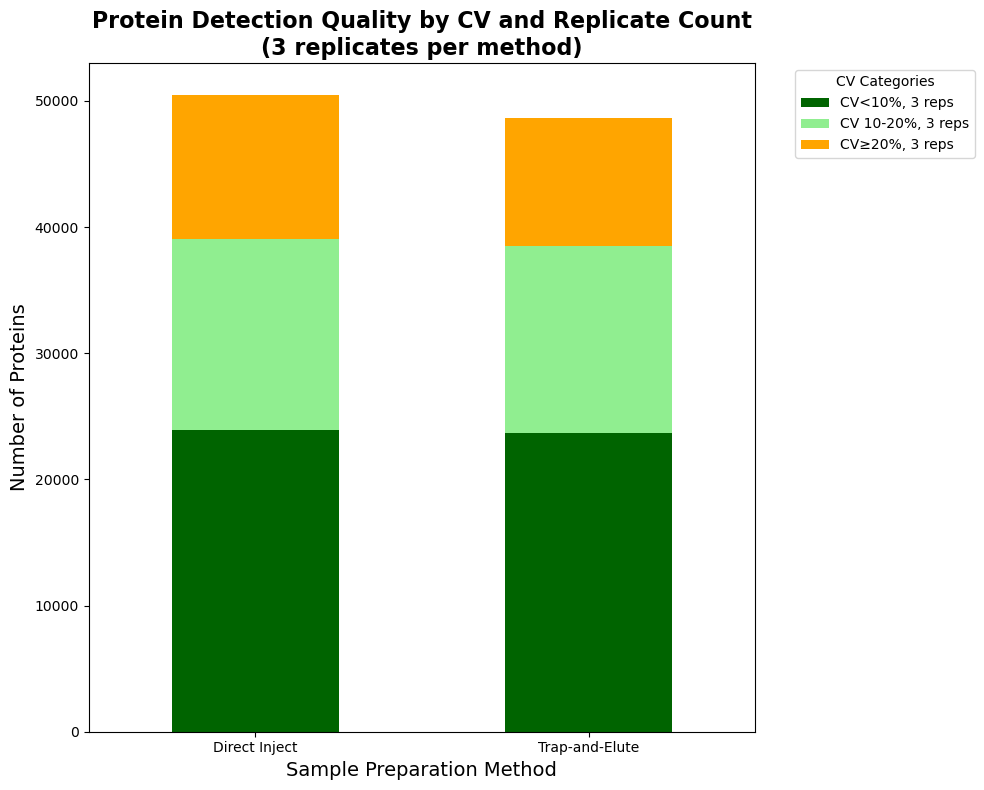


Direct Inject:
  Total proteins (≥2 replicates): 50486
  High precision (CV<10%): 23928 (47.4%)
  Medium precision (CV 10-20%): 15091 (29.9%)
  Lower precision (CV≥20%): 11467 (22.7%)

Trap-and-Elute:
  Total proteins (≥2 replicates): 48625
  High precision (CV<10%): 23668 (48.7%)
  Medium precision (CV 10-20%): 14859 (30.6%)
  Lower precision (CV≥20%): 10098 (20.8%)


In [315]:
# Create stacked bar plots for precursors with different CV thresholds and replicate counts
import matplotlib.pyplot as plt
import pandas as pd

# Define methods and CV thresholds
methods = ['20m150nlML30mA15phospho4', '33ML6mlInlineA15TrapNS5']
method_labels = ['Direct Inject', 'Trap-and-Elute']

# Initialize data storage for different categories
cv_rep_counts = {}

for i, method in enumerate(methods):
    cv_col = f'{method}_cv'
    rep_col = f'{method}_num_reps'
    
    # Get all data for this method (including proteins detected in 1, 2, or 3 replicates)
    method_data = trap_v_direct_summary[trap_v_direct_summary[rep_col] >= 1]
    
    # Count precursors in different CV and replicate categories
    cv_rep_counts[method_labels[i]] = {
        # CV < 10% categories
        'CV<10%, 2 reps': ((method_data[cv_col] < 10) & (method_data[rep_col] == 2)).sum(),
        'CV<10%, 3 reps': ((method_data[cv_col] < 10) & (method_data[rep_col] == 3)).sum(),
        
        # CV 10-20% categories  
        'CV 10-20%, 2 reps': ((method_data[cv_col] >= 10) & (method_data[cv_col] < 20) & (method_data[rep_col] == 2)).sum(),
        'CV 10-20%, 3 reps': ((method_data[cv_col] >= 10) & (method_data[cv_col] < 20) & (method_data[rep_col] == 3)).sum(),
        
        # CV ≥20% categories
        'CV≥20%, 2 reps': ((method_data[cv_col] >= 20) & (method_data[rep_col] == 2)).sum(),
        'CV≥20%, 3 reps': ((method_data[cv_col] >= 20) & (method_data[rep_col] == 3)).sum()
    }

# Convert to DataFrame for plotting
cv_rep_df = pd.DataFrame(cv_rep_counts).T

# Only keep columns that have non-zero values
non_zero_cols = cv_rep_df.columns[cv_rep_df.sum() > 0]
cv_rep_df_filtered = cv_rep_df[non_zero_cols]

# Reorder remaining columns for better visualization (best precision/reproducibility to worst)
available_cols = ['CV<10%, 3 reps', 'CV<10%, 2 reps', 'CV 10-20%, 3 reps', 
                  'CV 10-20%, 2 reps', 'CV≥20%, 3 reps', 'CV≥20%, 2 reps']
column_order = [col for col in available_cols if col in cv_rep_df_filtered.columns]
cv_rep_df_filtered = cv_rep_df_filtered[column_order]

print("CV and Replicate Distribution (proteins detected in ≥2 replicates):")
print(cv_rep_df_filtered)

# Create stacked bar plot with appropriate colors for the available categories
colors = ['darkgreen', 'lightgreen', 'orange', 'lightsalmon', 'red', 'lightcoral']
plot_colors = colors[:len(column_order)]

fig, ax = plt.subplots(figsize=(10, 8))
cv_rep_df_filtered.plot(kind='bar', stacked=True, ax=ax, color=plot_colors)

plt.title('Protein Detection Quality by CV and Replicate Count\n(3 replicates per method)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Sample Preparation Method', fontsize=14)
plt.ylabel('Number of Proteins', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='CV Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Calculate percentages for better interpretation
for method in method_labels:
    if method in cv_rep_df_filtered.index:
        total = cv_rep_df_filtered.loc[method].sum()
        high_quality_cols = [col for col in cv_rep_df_filtered.columns if 'CV<10%' in col]
        medium_quality_cols = [col for col in cv_rep_df_filtered.columns if 'CV 10-20%' in col]
        
        high_quality = cv_rep_df_filtered.loc[method, high_quality_cols].sum()
        medium_quality = cv_rep_df_filtered.loc[method, medium_quality_cols].sum()
        
        print(f"\n{method}:")
        print(f"  Total proteins (≥2 replicates): {total}")
        print(f"  High precision (CV<10%): {high_quality} ({high_quality/total*100:.1f}%)")
        print(f"  Medium precision (CV 10-20%): {medium_quality} ({medium_quality/total*100:.1f}%)")
        print(f"  Lower precision (CV≥20%): {total-high_quality-medium_quality} ({(total-high_quality-medium_quality)/total*100:.1f}%)")